In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [88]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['customer_id'], inplace= True)

    return df

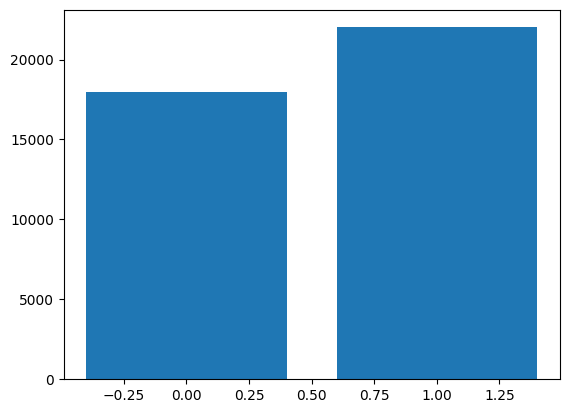

In [89]:
from sklearn.model_selection import train_test_split

train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X= preprocess_data(train_df.drop(columns=['loan_status']))
y= train_df['loan_status']

X_train, X_eval, y_train, y_eval= train_test_split(X, y, train_size=0.8, stratify=y, random_state= seed)

X_test= preprocess_data(test_df)

plt.bar(np.unique_counts(y).values, np.unique_counts(y).counts)
plt.show()

In [90]:
# Subtask 1

answer1= pd.DataFrame({
    'subtaskID': 1,
    'datapointID': test_df['customer_id'],
    'answer': test_df['age'].apply(lambda x: 'Young' if x < 30 else ('Adult' if x < 60 else 'Senior'))
})

answer1.head()

,subtaskID,datapointID,answer
0,1,CUST146767,Adult
1,1,CUST136829,Adult
2,1,CUST119409,Young
3,1,CUST112393,Young
4,1,CUST143342,Adult


In [96]:
# Subtask 2

answer2= pd.DataFrame({
    'subtaskID': 2,
    'datapointID': test_df['customer_id'],
    'answer': test_df['debt_to_income_ratio'].apply(lambda x: 'LowRisk' if x < 20 else ('MediumRisk' if x < 40 else 'HighRisk'))
})

answer2.head()

,subtaskID,datapointID,answer
0,2,CUST146767,LowRisk
1,2,CUST136829,LowRisk
2,2,CUST119409,LowRisk
3,2,CUST112393,LowRisk
4,2,CUST143342,LowRisk


In [92]:
# Subtask 3

answer3= pd.DataFrame({
    'subtaskID': 3,
    'datapointID': test_df['customer_id'],
    'answer': test_df[['current_debt', 'derogatory_marks', 'delinquencies_last_2yrs']].sum(axis= 1).astype(int)
})

answer3.head()

,subtaskID,datapointID,answer
0,3,CUST146767,4276
1,3,CUST136829,7063
2,3,CUST119409,6221
3,3,CUST112393,57212
4,3,CUST143342,7391


In [93]:
# Subtask 4

from catboost import CatBoostClassifier

cat_cols= X.select_dtypes(include=['object', 'str']).columns.to_list()

model= CatBoostClassifier(
    iterations= 3000,
    learning_rate= 0.03,
    depth= 6,
    cat_features= cat_cols,
    early_stopping_rounds= 200,
    auto_class_weights= 'Balanced',
    random_state= seed
)

model.fit(
    X_train, y_train,
    eval_set=[(X_eval, y_eval)],
    verbose= 200
)


0:	learn: 0.6644918	test: 0.6644708	best: 0.6644708 (0)	total: 17.5ms	remaining: 52.5s
200:	learn: 0.1932598	test: 0.1965290	best: 0.1965290 (200)	total: 4.05s	remaining: 56.9s
400:	learn: 0.1634689	test: 0.1725051	best: 0.1725051 (400)	total: 7.59s	remaining: 49.4s
600:	learn: 0.1481983	test: 0.1639965	best: 0.1639965 (600)	total: 10.7s	remaining: 42.9s
800:	learn: 0.1386864	test: 0.1608047	best: 0.1608004 (799)	total: 14.4s	remaining: 39.7s
1000:	learn: 0.1309271	test: 0.1592438	best: 0.1592438 (1000)	total: 18.2s	remaining: 36.5s
1200:	learn: 0.1240595	test: 0.1584664	best: 0.1584324 (1163)	total: 21.4s	remaining: 32.2s
1400:	learn: 0.1179084	test: 0.1579801	best: 0.1579792 (1364)	total: 24.6s	remaining: 28.2s
1600:	learn: 0.1125368	test: 0.1574755	best: 0.1574755 (1600)	total: 27.7s	remaining: 24.4s
1800:	learn: 0.1073211	test: 0.1574849	best: 0.1572844 (1644)	total: 31.1s	remaining: 20.8s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.1572844184
bestIteration

CatBoostClassifier(auto_class_weights='Balanced', cat_features=['occupation_status', 'product_type', 'loan_intent'], depth=6, early_stopping_rounds=200, iterations=3000, learning_rate=0.03, random_state=42)

In [94]:
predictions= model.predict_proba(X_test)[:, 1]

answer4= pd.DataFrame({
    'subtaskID': 4,
    'datapointID': test_df['customer_id'],
    'answer': predictions
})

answer4.head()

,subtaskID,datapointID,answer
0,4,CUST146767,0.000277
1,4,CUST136829,0.013339
2,4,CUST119409,0.997539
3,4,CUST112393,0.000004
4,4,CUST143342,0.207288


In [97]:
answer=pd.concat([answer1, answer2, answer3, answer4])
answer.to_csv("submission.csv", index= False)